In [2]:
# 실습 준비 - 패키지·폰트·장치 확인
#  오늘은 Colab 기본 패키지(numpy · pandas · pyarrow · matplotlib · torch)로 충분해 따로 설치하지 않습니다
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import torch
from torch import nn
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트: Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 직접 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색: 기준 모델=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다

print("사용 폰트:", FONT, "| 색 팔레트 준비 완료")

# 장치 확인: 신경망 셀이 모델과 입력을 옮길 곳(DEVICE)을 정합니다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = False   # fp32 로 계산해 GPU 종류에 따라 값이 갈리지 않게
torch.backends.cudnn.allow_tf32 = False

if DEVICE == "cuda":
    _gpu = torch.cuda.get_device_properties(0)
    print(f"DEVICE : cuda | GPU {torch.cuda.get_device_name(0)} | 메모리 {_gpu.total_memory / 1e9:.1f} GB"
          f" | torch {torch.__version__}")
else:
    print(f"DEVICE : cpu | torch {torch.__version__} | 오늘의 작은 MLP 는 CPU 로 충분합니다")
    print("GPU 를 쓰려면 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료
DEVICE : cpu | torch 2.14.1+cpu | 오늘의 작은 MLP 는 CPU 로 충분합니다
GPU 를 쓰려면 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다


In [3]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

100개 역 표 : 100개 역 x 4,199일 (2015-01-01 ~ 2026-06-30) · 빈칸 0개
표 1 · 베이스라인 셋의 두 묶음 평균 MASE (배)
  나이브 기법 : 공휴일 없는 두 주 1.622 · 공휴일 있는 세 주 4.031 · 전체 평균 3.067
  계절 나이브 : 공휴일 없는 두 주 0.445 · 공휴일 있는 세 주 2.767 · 전체 평균 1.838
  직전 7일 평균 : 공휴일 없는 두 주 1.935 · 공휴일 있는 세 주 3.684 · 전체 평균 2.984
표 2 · 승차 상위 10개 역과 하위 50개 역이 계절 나이브 제곱오차에서 차지하는 비중 (%)
  승차 상위 10개 역 (역 수 10%) : 표준화 없이 33.9 · 역마다 표준화 9.0
  승차 하위 50개 역 (역 수 50%) : 표준화 없이 22.7 · 역마다 표준화 52.4
표 3 · 예측 원점별 채점 7일과 평일 공휴일 (일)
  원점 2025-08-13   채점 08-13 ~ 08-19   평일 공휴일 1일   08-15 광복절
  원점 2025-10-01   채점 10-01 ~ 10-07   평일 공휴일 3일   10-03 개천절 · 10-06 추석 · 10-07 추석 다음 날
  원점 2025-12-10   채점 12-10 ~ 12-16   평일 공휴일 0일   없음
  원점 2026-02-11   채점 02-11 ~ 02-17   평일 공휴일 2일   02-16 설 전날 · 02-17 설날
  원점 2026-06-24   채점 06-24 ~ 06-30   평일 공휴일 0일   없음


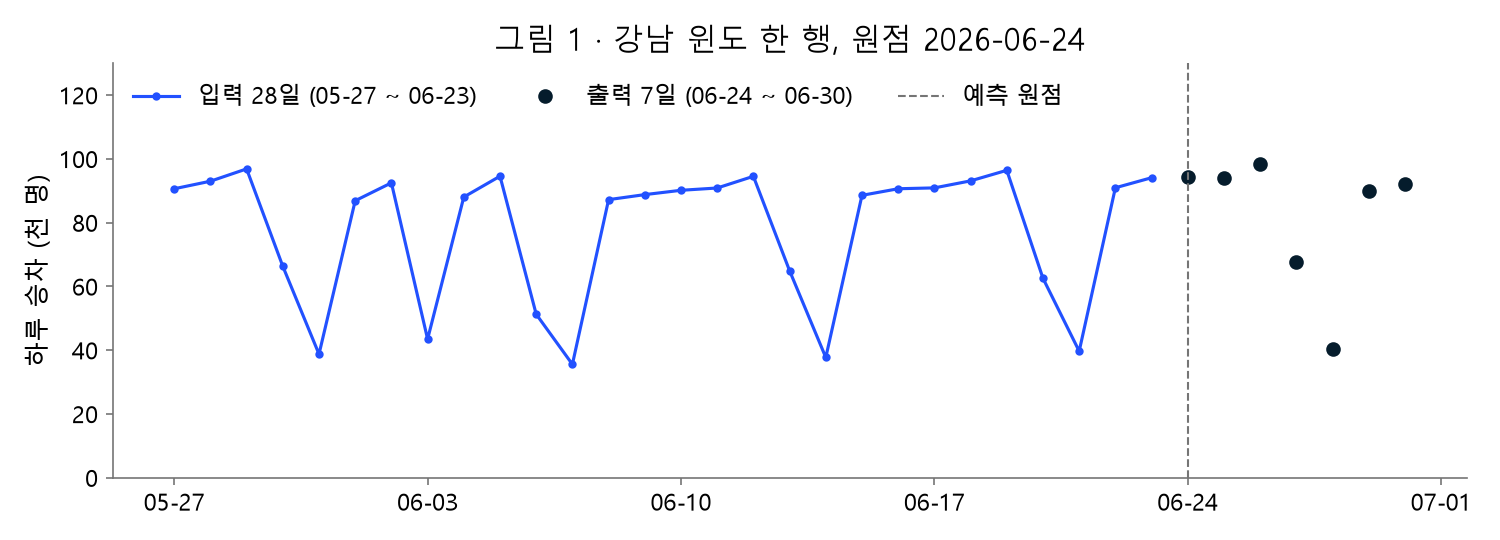

In [4]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 지하철 100개 역으로 표 1 · 표 2 · 표 3 · 그림 1 을 만듭니다. 자료를 처음 받을 때 30초 안팎 걸립니다
RAW_URL = ("https://github.com/studio-js/seoul-subway-ridership/raw/main/data/"
           "seoul_subway_daily_2015_2026.parquet")
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)
#  받아지지 않으면: 위 주소의 파일을 내려받아 Colab 왼쪽 파일 목록에 올린 뒤 이 셀을 다시 실행하세요

_raw = pd.read_parquet(CACHE)                  # 한 행이 (날짜, 호선, 역) 하루
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)   # 괄호 별칭을 뗀다
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})   # 갈린 호선 표기를 하나로
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) & (_span["max"] >= pd.Timestamp("2026-06-30"))
              & (_span["count"] >= 4190)]                                    # 기록이 끊기지 않은 계열
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")].groupby(["line", "station"])["board"]
        .mean().loc[_full.index].sort_values(ascending=False).index[:100])   # 2024년까지 평균 승차 상위 100개 역
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)              # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)        # 열의 날짜
STATIONS = [f"{_a} {_b}" for _a, _b in _wide.index]   # 행의 역 이름 (0번 = 2호선 강남)
ORIGINS = pd.to_datetime(["2025-08-13", "2025-10-01", "2025-12-10",
                          "2026-02-11", "2026-06-24"])   # 예측 원점 5개(모두 수요일)
PLAIN_ORIGINS = ORIGINS[[2, 4]]                # 공휴일 없는 두 주
HOL_ORIGINS = ORIGINS[[0, 1, 3]]               # 공휴일 있는 세 주
H = 7                                          # 채점 7일(원점 당일부터)
print(f"100개 역 표 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 ({DATES[0].date()} ~ {DATES[-1].date()})"
      f" · 빈칸 {int(np.isnan(MAT).sum())}개")


def _mase(o, pred):
    """원점 열 o 에서 역 x 7일 예측(명)의 역 단위 MASE. 분모는 원점 전날까지 계절 나이브의 평균 절대 오차"""
    past = MAT[:, :o]
    qden = np.mean(np.abs(past[:, 7:] - past[:, :-7]), axis=1)
    return float(np.mean(np.abs(MAT[:, o:o + H] - pred) / qden[:, None]))


# 표 1: 원점마다 베이스라인 셋을 역 단위 MASE 로 채점하고 두 묶음으로 나눠 평균한다
_by = {"naive": [], "snaive": [], "ma7": []}
for _og in ORIGINS:
    _o = DATES.get_loc(_og)
    _by["naive"].append(_mase(_o, np.repeat(MAT[:, _o - 1:_o], H, axis=1)))        # 원점 전날 값 하나를 7일에
    _by["snaive"].append(_mase(_o, MAT[:, _o - 7:_o]))                              # 1주일 전 같은 요일 값
    _by["ma7"].append(_mase(_o, np.repeat(MAT[:, _o - 7:_o].mean(axis=1, keepdims=True), H, axis=1)))  # 직전 7일 평균
BASE = {k: (float(np.mean([v[2], v[4]])), float(np.mean([v[0], v[1], v[3]])), float(np.mean(v)))
        for k, v in _by.items()}               # (공휴일 없는 두 주, 공휴일 있는 세 주, 전체) 평균 MASE
_names = {"naive": "나이브 기법", "snaive": "계절 나이브", "ma7": "직전 7일 평균"}
print("표 1 · 베이스라인 셋의 두 묶음 평균 MASE (배)")
for _k in ("naive", "snaive", "ma7"):
    print(f"  {_names[_k]} : 공휴일 없는 두 주 {BASE[_k][0]:.3f} · 공휴일 있는 세 주 {BASE[_k][1]:.3f}"
          f" · 전체 평균 {BASE[_k][2]:.3f}")

# 표 2: 원점 2026-06-24 의 학습 구간(원점 57일 전까지)에서 계절 나이브 제곱오차를 역마다 더해 묶음별 비중을 잰다
_o = DATES.get_loc(pd.Timestamp("2026-06-24"))
_cut = _o - 56                                  # 원점 직전 56일(검증 구간)은 뺀다
_hist = MAT[:, :_o]                             # 원점 전날까지
_rank = np.argsort(-_hist[:, -365:].mean(axis=1))   # 승차 순위 = 원점 전 365일 평균 승차
_mu = _hist[:, :_cut].mean(axis=1, keepdims=True)   # 역마다 원점 57일 전까지로 잰 평균 · 표준편차
_sd = _hist[:, :_cut].std(axis=1, keepdims=True)
_z = (_hist - _mu) / _sd                          # 역마다 표준화한 승차
_se = {"raw": ((_hist[:, 7:_cut] - _hist[:, :_cut - 7]) ** 2).sum(axis=1),   # 명 단위 제곱오차
       "std": ((_z[:, 7:_cut] - _z[:, :_cut - 7]) ** 2).sum(axis=1)}         # 표준화한 값의 제곱오차
SHARE = {f"{_k}_{_g}": float(_se[_k][_idx].sum() / _se[_k].sum())
         for _k in ("raw", "std") for _g, _idx in (("top10", _rank[:10]), ("bottom50", _rank[50:]))}
print("표 2 · 승차 상위 10개 역과 하위 50개 역이 계절 나이브 제곱오차에서 차지하는 비중 (%)")
for _g, _n in (("top10", "승차 상위 10개 역 (역 수 10%)"), ("bottom50", "승차 하위 50개 역 (역 수 50%)")):
    print(f"  {_n} : 표준화 없이 {100 * SHARE['raw_' + _g]:.1f} · 역마다 표준화 {100 * SHARE['std_' + _g]:.1f}")

# 표 3: 채점 7일 안의 평일(월~금) 공휴일. 대한민국 공휴일 가운데 원점 5개의 채점 7일 안에 있는 날만 옮겼다
KR_HOLIDAYS = {"2025-08-15": "광복절", "2025-10-03": "개천절", "2025-10-05": "추석 전날",
               "2025-10-06": "추석", "2025-10-07": "추석 다음 날", "2026-02-16": "설 전날",
               "2026-02-17": "설날"}
WH_COUNT = {}                                   # 원점 날짜 -> 채점 7일 가운데 평일 공휴일 수
print("표 3 · 예측 원점별 채점 7일과 평일 공휴일 (일)")
for _og in ORIGINS:
    _days = pd.date_range(_og, periods=H)
    _wh = [d for d in _days if d.strftime("%Y-%m-%d") in KR_HOLIDAYS and d.dayofweek < 5]
    WH_COUNT[str(_og.date())] = len(_wh)
    _txt = " · ".join(f"{d:%m-%d} {KR_HOLIDAYS[d.strftime('%Y-%m-%d')]}" for d in _wh) or "없음"
    print(f"  원점 {_og.date()}   채점 {_days[0]:%m-%d} ~ {_days[-1]:%m-%d}   평일 공휴일 {len(_wh)}일   {_txt}")

# 그림 1: 원점 2026-06-24 에서 강남의 윈도 한 행. 입력 28일은 원점 전날에서 끝나고 출력 7일은 원점 당일부터
_g, _o = STATIONS.index("2호선 강남"), DATES.get_loc(pd.Timestamp("2026-06-24"))
fig, ax = plt.subplots(figsize=(FIG_W, 3.6))
ax.plot(DATES[_o - 28:_o], MAT[_g, _o - 28:_o] / 1000, marker="o", ms=3, color=COL["파랑"],
        label="입력 28일 (05-27 ~ 06-23)")
ax.plot(DATES[_o:_o + H], MAT[_g, _o:_o + H] / 1000, "o", color=COL["남색"], label="출력 7일 (06-24 ~ 06-30)")
ax.axvline(DATES[_o], color=COL["회색"], ls="--", lw=1, label="예측 원점")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=2))   # 눈금은 수요일마다(원점과 같은 요일)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_title("그림 1 · 강남 윈도 한 행, 원점 2026-06-24")
ax.set_ylabel("하루 승차 (천 명)")
ax.set_ylim(0, 130)
ax.legend(frameon=False, loc="upper left", ncol=3)
plt.show()

# 채점 지표가 다른 두 팀은 각각 어떤 손실로 학습하나
예를 들어 A 팀은 역 단위 MASE 로, B 팀은 RMSE 로 다음 주 예측을 채점합니다.

B. A 팀은 MAE, B 팀은 MSE: 손실을 각자 채점 지표에 맞춘다

A 팀은 MAE, B 팀은 MSE 로 학습합니다. 「5. 손실 MSE 와 MAE」 의 손실과 채점 지표 표처럼, 오차를 세는 방식이 같은 손실과 채점 지표를 함께 쓰기 때문입니다.

손실은 학습할 때 모델이 줄이는 값이고, 채점 지표는 학습 뒤 평가표에 적는 값입니다. A 팀의 MASE 는 그 역의 MAE 를 정해진 수 Q 
i
​
  로 나눈 값이라, MAE 를 줄이면 MASE 도 줄어듭니다. 잠실은 Q 
i
​
  가 6,405.5명이라 MAE 가 3,203명에서 2,000명으로 줄면 MASE 는 3,203 ÷ 6,405.5 = 0.500 에서 2,000 ÷ 6,405.5 = 0.312 로 줄어듭니다. B 팀의 RMSE 는 MSE 의 제곱근이라 크기 순서가 MSE 와 같습니다. MSE 가 4,000,000명² 과 9,000,000명² 인 두 예측은 RMSE 로 2,000명과 3,000명입니다.

두 팀 모두 MSE: 「신경망 손실은 MSE」는 습관이지 규칙이 아닙니다. 강남 개천절 주 다섯 날을 숫자 하나로 예측하면 MSE 는 평균 80.42천 명을 골라 다른 네 날보다 8～10천 명 낮게 예측합니다. 다섯 날의 MAE 로 계산하면 80.42천 명은 14.69천 명, MAE 손실이 고르는 중앙값 89.7천 명은 9.64천 명이라 A 팀에는 MSE 손실이 고른 값이 더 나쁩니다.
두 팀 모두 MAE: MAE 는 같은 다섯 날에서 중앙값 89.7 을 골라 개천절 43.7천 명을 46.0천 명 빗나갑니다. RMSE 로 계산하면 89.7 은 약 20.6천 명, 80.42 는 약 18.4천 명이라 B 팀에는 MAE 손실이 고른 값이 더 나쁩니다.
그래서 학습 코드를 쓰기 전에 평가표의 채점 지표부터 확인하고, MASE 로 채점하면 nn.L1Loss(), RMSE 로 채점하면 nn.MSELoss() 를 적습니다.

핵심 키워드: 손실은 채점 지표에 맞춘다, MSE 는 평균 · MAE 는 중앙값, nn.L1Loss

# 표준화한 예측을 채점하기 전에 무엇을 하나
예를 들어 큰 역(평균 80,000명, 표준편차 20,000명)과 작은 역(평균 16,000명, 표준편차 4,000명)에서 모델이 두 역 모두 표준화 예측 0.5 를 냈습니다.

C. 역마다 자기 표준편차를 곱하고 자기 평균을 더해 명으로 되돌린다

역마다 자기 표준편차를 곱하고 자기 평균을 더해 명으로 되돌립니다. 「3. 글로벌 모델과 계열별 표준화」 의 계열별 표준화에서 모델은 역마다 z=(y−μ i)/σ i로 바꾼 값을 배웠으므로, 예측도 그 역의 값으로 y^ = z^ ×σ i +μ i를 거쳐야 명이 되기 때문입니다.

두 역에 대입하면 큰 역은 0.5 × 20,000 + 80,000 = 90,000명이고, 작은 역은 0.5 × 4,000 + 16,000 = 18,000명입니다. 같은 0.5 는 두 역 모두 평소보다 표준편차의 절반만큼 많은 날이라는 뜻이고, 명으로는 90,000 ÷ 18,000 = 5배 차이입니다.

두 역 모두 0.5 를 그대로 채점에 쓴다: 수만 명인 실제 승차를 0.5명으로 예측한 셈입니다. 큰 역의 실제가 90,000명이면 오차가 약 90,000명이라, MASE 에는 모델의 오차가 아니라 단위 차이가 담깁니다.
100개 역 전체의 평균·표준편차 하나로 되돌린다: 두 역이 같은 0.5 를 냈으므로 명으로 바꾼 값도 같은 명수 하나입니다. 90,000명과 18,000명을 한 수로 맞힐 수는 없어 적어도 한 역은 크게 빗나갑니다.
그래서 되돌릴 때도 표준화에 쓴 역별 평균·표준편차를 그대로 씁니다. 실습의 MLP 도 원점 57일 전까지의 자료로 잰 역별 값으로 예측을 되돌린 뒤 역 단위 MASE 를 냅니다.

핵심 키워드: 계열별 표준화, 예측 × 표준편차 + 평균, 명 단위로 채점

# 새 신경망을 비교할 베이스라인
「오늘의 준비」 셀을 실행하면 나오는 「표 1 · 베이스라인 셋의 두 묶음 평균 MASE (배)」를 봅니다. 새 신경망의 MASE 는 어느 베이스라인과 비교해 투입을 판단할까요?

A. 계절 나이브: 두 묶음 모두 셋 가운데 가장 낮다

계절 나이브와 비교합니다. 표 1 에서 계절 나이브가 두 묶음 모두 셋 가운데 가장 낮고, 「1. 예측 원점과 역 단위 MASE」 에서 새 모델을 쓰려면 먼저 공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮아야 한다고 정했기 때문입니다.

표 1 의 두 묶음 평균은 계절 나이브 0.445 · 2.767, 직전 7일 평균 1.935 · 3.684, 나이브 기법 1.622 · 4.031 입니다. 공휴일 없는 두 주에서 직전 7일 평균은 계절 나이브의 1.935 ÷ 0.445 ≈ 4.35배, 나이브 기법은 1.622 ÷ 0.445 ≈ 3.64배 빗나갑니다. 공휴일 있는 세 주에서도 3.684 ÷ 2.767 ≈ 1.33배, 4.031 ÷ 2.767 ≈ 1.46배입니다.

직전 7일 평균: 지금 역 운영팀이 쓰는 방식이지만 셋 가운데 가장 낮지 않습니다. 이것보다만 낮으면 된다고 보면, 공휴일 없는 두 주에 0.445 와 1.935 사이를 받는 모델도 쓰게 됩니다. 1주일 전 값을 예측값으로 쓰는 계절 나이브보다 더 빗나가는 모델입니다.
MASE 1: 1 은 원점 전날까지 그 역에서 계절 나이브가 평소 빗나가던 크기입니다. 같은 주의 계절 나이브와 비교한 값이 아니어서, 공휴일 있는 세 주에서는 계절 나이브 자신이 2.767 로 1 보다 큽니다. 공휴일 없는 두 주에 0.445 와 1 사이를 받는 모델은 1 보다 작아도 계절 나이브보다 더 빗나간 것입니다.
그래서 평가표에는 새 모델의 두 묶음 평균을 계절 나이브와 나란히 적고, 공휴일 없는 두 주에서 0.445 보다 낮은지부터 봅니다.

핵심 키워드: 같은 평가표의 계절 나이브, 두 묶음으로 비교한다, MASE 1 은 과거 평균 오차의 크기

# 표준화 없이 모은 모델의 작은 손실
「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 승차 상위 10개 역과 하위 50개 역이 계절 나이브 제곱오차에서 차지하는 비중 (%)」를 봅니다. 역마다 오차 크기는 승차 규모를 따르므로, 1주일 전 값을 예측값으로 쓰는 계절 나이브의 제곱오차 비중으로 모델 손실에서 각 역이 차지할 무게를 어림합니다. 표준화 없이 100개 역을 모아 제곱 오차로 학습한 모델의 손실이 작으면, 100개 역을 고르게 맞힌다고 믿어도 될까요?

B. 믿기 어렵다: 계절 나이브 제곱오차의 약 3분의 1 이 승차 상위 10개 역에서 나온다

믿기 어렵습니다. 표 2 에서 표준화 없이 모으면 승차 상위 10개 역이 계절 나이브 제곱오차의 33.9%, 약 3분의 1 을 차지하기 때문입니다. 「3. 글로벌 모델과 계열별 표준화」 의 규모 차이처럼, 명 단위 그대로 모아 학습하면 모델은 큰 역의 오차부터 줄입니다.

상위 10개 역은 역 수로 10% 인데 비중이 33.9% 라, 역 하나가 33.9 ÷ 10 ≈ 3.4% 씩 차지합니다. 하위 50개 역은 22.7 ÷ 50 ≈ 0.45% 씩이라, 상위 역 하나가 하위 역 하나의 약 7.5배 무게로 손실에 들어갑니다. 역마다 표준화하면 상위 10개 역은 9.0%, 하위 50개 역은 52.4% 로 역 수 비율 10% · 50% 에 가까워집니다.

믿어도 된다: 100개 역이 같은 무게라면 상위 10개 역의 비중이 역 수 비율인 10% 안팎이어야 합니다. 표준화 없이는 33.9% 라 손실이 작다는 말은 큰 역을 잘 맞혔다는 뜻일 수 있습니다.
믿기 어렵다, 대부분이 하위 50개 역에서 나온다: 표 2 를 거꾸로 읽은 것입니다. 하위 50개 역은 역 수로 절반인데 표준화 없이는 22.7% 만 차지합니다.
그래서 100개 역을 모을 때는 역마다 원점 57일 전까지의 자료로 표준화한 뒤 학습하고, 결과는 손실 값 하나가 아니라 역 단위 MASE 로 평가표에 적습니다.

핵심 키워드: 큰 역이 손실을 차지한다, 계열별 표준화, 역 단위 MASE 로 평가

# 공휴일 있는 세 주의 원점 고르기
「오늘의 준비」 셀을 실행하면 나오는 「표 3 · 예측 원점별 채점 7일과 평일 공휴일 (일)」을 봅니다. 채점 7일에 평일 공휴일이 있어 「공휴일 있는 세 주」로 묶이는 원점은?

A. 2025-08-13 · 2025-10-01 · 2026-02-11

2025-08-13 · 2025-10-01 · 2026-02-11 입니다. 표 3 에서 이 세 원점만 채점 7일에 평일 공휴일이 1일 이상이고, 「1. 예측 원점과 역 단위 MASE」 에서 두 묶음을 채점 7일의 월～금에 공휴일이 하루라도 있는지로 나눴기 때문입니다.

표 3 의 평일 공휴일은 원점 2025-08-13 이 1일(08-15 광복절), 2025-10-01 이 3일(10-03 개천절 · 10-06 추석 · 10-07 추석 다음 날), 2026-02-11 이 2일(02-16 설 전날 · 02-17 설날)입니다. 2025-12-10 과 2026-06-24 는 0일이라 공휴일 없는 두 주입니다. 다섯 주를 더하면 1 + 3 + 0 + 2 + 0 = 6일이고, 6일 × 100개 역 = 600개 값은 채점하는 35일 × 100개 역 = 3,500개 값의 17% 입니다. KR_HOLIDAYS 의 10-05 추석 전날은 일요일이라 평일 공휴일이 아닙니다.

2025-10-01 · 2025-12-10 · 2026-02-11: 12월이라 연말 휴일이 있다고 짐작한 것입니다. 원점 2025-12-10 의 채점 7일은 12-10～12-16 이라 성탄절 12-25 가 들어가지 않고, 평일 공휴일이 1일인 2025-08-13 이 빠졌습니다.
2025-08-13 · 2025-10-01 · 2026-06-24: 원점 2026-06-24 의 채점 7일인 06-24～06-30 에는 공휴일이 없고, 평일 공휴일이 2일인 2026-02-11 이 빠졌습니다.
그래서 평가표에는 원점마다 평일 공휴일 수를 한 열로 두고, 공휴일 없는 두 주와 공휴일 있는 세 주의 평균을 따로 적습니다.

핵심 키워드: 평일 공휴일, 공휴일 있는 세 주, 두 묶음 평균을 따로

In [5]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
RAW_URL = ("https://github.com/studio-js/seoul-subway-ridership/raw/main/data/"
           "seoul_subway_daily_2015_2026.parquet")
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 「오늘의 준비」와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 계열만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 행의 역 이름

L, H, VAL_DAYS = 28, 7, 56                    # 입력 28일 · 출력 7일 · 검증 구간 56일
ORIGIN_PLAIN = "2025-12-10"                  # 공휴일 없는 주의 원점 (채점 7일에 평일 공휴일 없음)
ORIGIN_HOLIDAY = "2025-10-01"                # 공휴일 있는 주의 원점 (채점 7일에 개천절 · 추석 · 추석 다음 날)
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다


def origin_ctx(origin):
    """원점 하나의 자료: 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden), 원점의 열 번호(o)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def zstats(A):
    """역별 평균과 표준편차 (표준편차가 0 인 역은 1 로 둡니다)"""
    mu = np.nanmean(A, axis=1, keepdims=True)
    sd = np.nanstd(A, axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    return mu, sd


def make_windows(M, t_lo, t_hi):
    """첫 목표일의 열 번호가 t_lo ~ t_hi 인 (입력 28일, 정답 7일) 윈도를 역마다 모두 뽑아 한 표로 모읍니다"""
    W = np.lib.stride_tricks.sliding_window_view(M, L + H, axis=1)
    Wsel = W[:, t_lo - L:t_hi - L + 1, :]
    X = Wsel[..., :L].reshape(-1, L).astype(np.float32)
    Y = Wsel[..., L:].reshape(-1, H).astype(np.float32)
    ok = np.isfinite(X).all(1) & np.isfinite(Y).all(1)
    return X[ok], Y[ok]


class MLP(nn.Module):
    """입력 28 → 64 → ReLU → 64 → ReLU → 출력 7. seed 가 첫 가중치를 정합니다"""

    def __init__(self, seed=0, hidden=64):
        torch.manual_seed(seed)
        super().__init__()
        self.net = nn.Sequential(nn.Linear(L, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, H))

    def forward(self, x):
        return self.net(x)


def train_loop(model, Xtr, Ytr, Xva, Yva, loss="mse", batch=256, max_epochs=30, patience=5,
               seed=0, device=DEVICE):
    """조기 종료를 붙인 학습: 검증 손실이 patience 에폭 이어서 나아지지 않으면 멈추고 가장 좋았던 에폭으로 되돌립니다"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    lossf = nn.MSELoss() if loss == "mse" else nn.L1Loss()          # 손실은 이 한 줄에서만 갈린다
    Xtr_t, Ytr_t = torch.from_numpy(Xtr).to(device), torch.from_numpy(Ytr).to(device)
    Xva_t, Yva_t = torch.from_numpy(Xva).to(device), torch.from_numpy(Yva).to(device)
    gen = torch.Generator().manual_seed(seed)          # 섞는 순서는 CPU 에서 정해 DEVICE 가 달라도 같게 둡니다
    n = len(Xtr_t)
    best, best_state, best_ep, bad, stop_ep = float("inf"), None, -1, 0, None
    for ep in range(1, max_epochs + 1):
        model.train()
        perm = torch.randperm(n, generator=gen)
        for i in range(0, n, batch):
            idx = perm[i:i + batch].to(device)
            optimizer.zero_grad()
            lossf(model(Xtr_t[idx]), Ytr_t[idx]).backward()
            optimizer.step()                           # 경사하강법 한 걸음: 손실이 줄어드는 쪽으로 가중치를 옮긴다
        model.eval()
        with torch.no_grad():
            val = lossf(model(Xva_t), Yva_t).item()    # 검증 구간의 윈도에서 잰 손실
        if val < best - 1e-7:                          # 지금까지 가장 낮으면 가중치를 보관한다
            best, best_ep, bad = val, ep, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:                        # patience 에폭 이어서 나아지지 않으면 멈춘다
                stop_ep = ep
                break
    model.load_state_dict(best_state)                  # 멈춘 에폭이 아니라 가장 좋았던 에폭의 가중치로
    model.eval()
    return dict(stop_epoch=stop_ep, best_epoch=best_ep, best_val=best)


def predict(model, x, mu, sd):
    """입력의 끝 28일로 7일을 예측하고 표준화를 풀어 명 단위로 바꿉니다 (모델과 같은 DEVICE 에서 계산)"""
    dev = next(model.parameters()).device
    with torch.no_grad():
        out = model(torch.from_numpy(np.asarray(x)[:, -L:].astype(np.float32)).to(dev))
    return out.cpu().numpy().astype(float) * sd + mu


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


def fit_global(origin, loss="mse", seed=SEED, device=DEVICE):
    """원점 전날에서 끝나는 입력 28일로 100개 역 글로벌 MLP 를 학습하고 채점 7일 MASE 를 돌려준다.

    loss : "mse" · "mae"
    반환 : mase · point(100 x 7 예측, 명) · y(채점 7일 실제, 명) · qden · best_epoch · stop_epoch · device
    """
    if loss not in ("mse", "mae"):
        raise ValueError(f'loss 는 "mse" 또는 "mae" 입니다 (지금 {loss!r})')
    ctx = origin_ctx(origin)
    hist, o = ctx["hist"], ctx["o"]
    val_first = o - VAL_DAYS                            # 원점 직전 56일의 첫날
    mu, sd = zstats(hist[:, :val_first])                # 계열별 표준화 통계 = 원점 57일 전까지
    M = (hist - mu) / sd
    Xtr, Ytr = make_windows(M, L, val_first - H)        # 학습 윈도: 목표 7일이 원점 57일 전까지 끝난다
    Xva, Yva = make_windows(M, val_first, o - H)        # 검증 구간의 윈도: 목표 7일이 원점 직전 56일 안에서 끝난다
    model = MLP(seed=seed)
    res = train_loop(model, Xtr, Ytr, Xva, Yva, loss=loss, seed=seed, device=device)   # 손실만 인자로 바뀝니다
    pred = predict(model, M, mu, sd)                    # 원점 전날에서 끝나는 28일 → 7일, 명 단위
    mase = score(ctx["test"], pred, ctx["qden"])["mase"]  # 채점 7일은 여기에서만 씁니다
    return dict(origin=origin, loss=loss, mase=mase, point=pred, y=ctx["test"], qden=ctx["qden"],
                best_epoch=res["best_epoch"], stop_epoch=res["stop_epoch"],
                device=str(next(model.parameters()).device))


SNAIVE_TWO = {}                               # 두 원점의 계절 나이브 MASE
for _og in (ORIGIN_PLAIN, ORIGIN_HOLIDAY):
    _c = origin_ctx(_og)
    SNAIVE_TWO[_og] = score(_c["test"], _c["hist"][:, -7:], _c["qden"])["mase"]   # 원점 앞 7일을 다음 7일로

# 본문 수 확인: 강남역, 개천절이 있는 주의 평일 5일 (자료가 바뀌면 여기서 멈춥니다)
_gn = STATIONS.index("2호선 강남")
_wk = MAT[_gn, DATES.get_loc(pd.Timestamp("2025-09-29")):DATES.get_loc(pd.Timestamp("2025-10-03")) + 1]
assert [int(v) for v in _wk] == [88403, 90415, 89889, 89738, 43721]
assert (round(SNAIVE_TWO[ORIGIN_PLAIN], 3), round(SNAIVE_TWO[ORIGIN_HOLIDAY], 3)) == (0.419, 4.388)
print(f"100개 역 표 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print(f"원점 {ORIGIN_PLAIN}(공휴일 없는 주) · 원점 {ORIGIN_HOLIDAY}(공휴일 있는 주) : 원점마다 원점 전날까지의 자료로 다시 학습합니다")
print("계절 나이브 MASE :", " · ".join(f"{k} {v:.3f}" for k, v in SNAIVE_TWO.items()))
print(f"학습 조건 : 입력 {L}일 · 출력 {H}일 · 검증 구간 원점 직전 {VAL_DAYS}일 · 조기 종료 5에폭"
      f" · 시드 {SEED} · DEVICE {DEVICE}. 손실만 fit_global 의 loss 로 고릅니다")
print("쓸 수 있는 이름 : ORIGIN_PLAIN · ORIGIN_HOLIDAY · fit_global(origin, loss, seed=SEED)"
      " · SNAIVE_TWO · SEED · DEVICE")

100개 역 표 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 2025-12-10(공휴일 없는 주) · 원점 2025-10-01(공휴일 있는 주) : 원점마다 원점 전날까지의 자료로 다시 학습합니다
계절 나이브 MASE : 2025-12-10 0.419 · 2025-10-01 4.388
학습 조건 : 입력 28일 · 출력 7일 · 검증 구간 원점 직전 56일 · 조기 종료 5에폭 · 시드 0 · DEVICE cpu. 손실만 fit_global 의 loss 로 고릅니다
쓸 수 있는 이름 : ORIGIN_PLAIN · ORIGIN_HOLIDAY · fit_global(origin, loss, seed=SEED) · SNAIVE_TWO · SEED · DEVICE


공휴일 없는 주 MASE 차(MSE-MAE): 0.2
공휴일 있는 주 MASE 차(MSE-MAE): -0.316


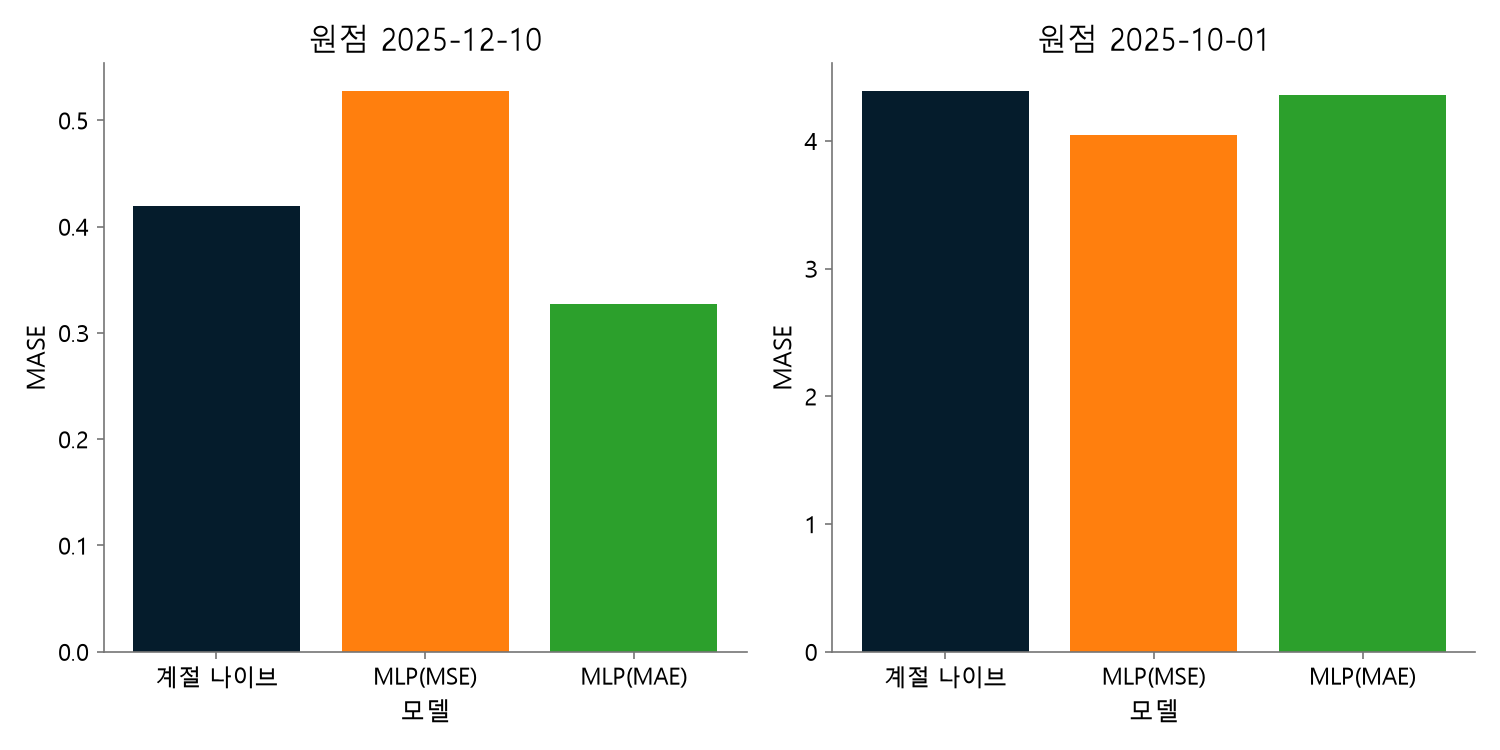

In [7]:
# 미션 1 — 프롬프트   # ai: prompt
# [heavy] 학습을 네 번 해서 CPU 로 2～3분 걸립니다. PROMPT 를 비우면 학습이 끝난 뒤에야 ❌ 가 나옵니다
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
아래 출력물 나오도록 코드 작성해줘 다만, 쓸 수 있는 것: 「미션 1 준비 셀」이 만들어 둔 이름에 명시된 변수들은 추가 생성하지말고 그대로 사용해
1. 공휴일 없는 주 MASE 차(MSE = MAE): 단위 없음, 소수 셋째자리까지
ORIGIN_PLAN에서 MLP MASE에서 MLP MASE를 뺀 값
2. 공휴일 있는 주 MASE 차(MSE - MAE): 단위 없음, 소수 셋째자리까지
ORIGIN_HOLIDAY에서 1번과 동일한 순서로 뺀 값
3. 그래프(그림 2개)
왼쪽: 공휴일 없는 주
오른쪽: 공휴일 있는 주
제목에 원점 날짜 기재
그림마다 계절 나이브, MLP(MSE 손실), MLP(MAE 손실) 막대 3개
가로축 이름: 모델
세로축 이름: MASE
"""
# --- 여기부터 AI 코드 ---
import matplotlib.pyplot as plt

res_plain_mse = fit_global(ORIGIN_PLAIN, "mse", seed=SEED)
res_plain_mae = fit_global(ORIGIN_PLAIN, "mae", seed=SEED)
res_holiday_mse = fit_global(ORIGIN_HOLIDAY, "mse", seed=SEED)
res_holiday_mae = fit_global(ORIGIN_HOLIDAY, "mae", seed=SEED)

diff_plain = round(res_plain_mse["mase"] - res_plain_mae["mase"], 3)
diff_holiday = round(res_holiday_mse["mase"] - res_holiday_mae["mase"], 3)

print(f"공휴일 없는 주 MASE 차(MSE-MAE): {diff_plain}")
print(f"공휴일 있는 주 MASE 차(MSE-MAE): {diff_holiday}")

models = ["계절 나이브", "MLP(MSE)", "MLP(MAE)"]

fig, axes = plt.subplots(1, 2, figsize=(FIGW, FIGW / 2))

vals_plain = [SNAIVE_TWO[ORIGIN_PLAIN], res_plain_mse["mase"], res_plain_mae["mase"]]
axes[0].bar(models, vals_plain, color=[COL.get("남색", "C0"), COL.get("빨강", "C1"), COL.get("초록", "C2")])
axes[0].set_title(f"원점 {ORIGIN_PLAIN}")
axes[0].set_xlabel("모델")
axes[0].set_ylabel("MASE")

vals_holiday = [SNAIVE_TWO[ORIGIN_HOLIDAY], res_holiday_mse["mase"], res_holiday_mae["mase"]]
axes[1].bar(models, vals_holiday, color=[COL.get("남색", "C0"), COL.get("빨강", "C1"), COL.get("초록", "C2")])
axes[1].set_title(f"원점 {ORIGIN_HOLIDAY}")
axes[1].set_xlabel("모델")
axes[1].set_ylabel("MASE")

plt.tight_layout()
plt.show()

In [8]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
# [heavy] 원점 5개마다 글로벌 MLP(MSE 손실)의 가중치를 학습하는 계산이 들어 있어 CPU 로 1～2분 걸립니다
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 모델과 입력을 둘 곳(GPU 또는 CPU)
torch.backends.cuda.matmul.allow_tf32 = False              # 예측도 fp32 로, GPU 가 자릿수를 줄인 계산(TF32)을 쓰지 않게

RAW_URL = ("https://github.com/studio-js/seoul-subway-ridership/raw/main/data/"
           "seoul_subway_daily_2015_2026.parquet")
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)
#  받아지지 않으면: 위 주소의 파일을 내려받아 Colab 왼쪽 파일 목록에 올린 뒤 이 셀을 다시 실행하세요

_raw = pd.read_parquet(CACHE)                  # 「오늘의 준비」와 같은 정제와 100개 역 표를 이 셀이 다시 만듭니다
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")].groupby(["line", "station"])["board"]
        .mean().loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 행렬 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 행렬 열의 날짜
STATIONS = [f"{_a} {_b}" for _a, _b in _wide.index]   # 행렬 행의 역 이름 (0번 = 2호선 강남)
ORIGINS = pd.to_datetime(["2025-08-13", "2025-10-01", "2025-12-10",
                          "2026-02-11", "2026-06-24"])        # 원점 5개(예측 첫날)
PLAIN_ORIGINS = ORIGINS[[2, 4]]               # 공휴일 없는 두 주
HOL_ORIGINS = ORIGINS[[0, 1, 3]]              # 공휴일 있는 세 주
L, H = 28, 7                                  # 입력 28일, 채점 7일


def qden_of(origin):
    """원점 전날까지의 자료로 역마다 구한 MASE 분모(계절 나이브의 평균 절대 오차, 명)를 돌려줍니다"""
    o = DATES.get_loc(pd.Timestamp(origin))
    past = MAT[:, :o]
    return np.mean(np.abs(past[:, 7:] - past[:, :-7]), axis=1)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


class _MLP(nn.Module):      # 이름 앞 밑줄: 미션 1 준비 셀의 MLP(seed 인자를 받는다)와 겹치지 않게
    """입력 28 → 64 → ReLU → 64 → ReLU → 출력 7"""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(L, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, H))

    def forward(self, x):
        return self.net(x)


def _windows(Z, t_lo, t_hi):
    """첫 출력일이 t_lo ~ t_hi 인 윈도(입력 28일, 출력 7일)를 역마다 잘라 한 표로 모은다"""
    W = np.lib.stride_tricks.sliding_window_view(Z, L + H, axis=1)[:, t_lo - L:t_hi - L + 1, :]
    return (W[..., :L].reshape(-1, L).astype(np.float32),
            W[..., L:].reshape(-1, H).astype(np.float32))


def _train(model, Xtr, Ytr, Xva, Yva, batch=256, max_epochs=30, patience=5, seed=0):
    """MSE 손실과 조기 종료로 학습하고 가장 좋았던 에폭의 가중치로 되돌립니다 (CPU)"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    lossf = nn.MSELoss()
    Xtr_t, Ytr_t, Xva_t, Yva_t = map(torch.from_numpy, (Xtr, Ytr, Xva, Yva))
    gen = torch.Generator().manual_seed(seed)
    best, best_state, bad = float("inf"), None, 0
    for ep in range(1, max_epochs + 1):
        model.train()
        perm = torch.randperm(len(Xtr_t), generator=gen)
        for i in range(0, len(Xtr_t), batch):
            idx = perm[i:i + batch]
            optimizer.zero_grad()
            lossf(model(Xtr_t[idx]), Ytr_t[idx]).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val = lossf(model(Xva_t), Yva_t).item()
        if val < best - 1e-7:
            best, bad = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()


def _fit_weights(origin):
    """원점 전날까지의 자료만으로 글로벌 MLP 의 가중치를 학습한다 (이 셀이 대신하는 계산입니다)"""
    o = DATES.get_loc(origin)
    past = MAT[:, :o]                                   # 원점 전날까지
    cut = o - 56
    mu = past[:, :cut].mean(axis=1, keepdims=True)      # 역별 평균·표준편차: 원점 57일 전까지로 잰 값
    sd = past[:, :cut].std(axis=1, keepdims=True)
    Z = (past - mu) / sd
    Xtr, Ytr = _windows(Z, L, cut - H)                  # 학습 윈도: 목표일이 원점 57일 전까지
    Xva, Yva = _windows(Z, cut, o - H)                  # 검증 구간: 목표일이 원점 직전 56일인 윈도
    torch.manual_seed(0)
    model = _MLP()
    _train(model, Xtr, Ytr, Xva, Yva, seed=0)
    return model, mu[:, 0], sd[:, 0]


MODELS, MU, SD = {}, {}, {}                   # 원점 -> 모델(DEVICE 로 옮김) · 역별 평균 · 역별 표준편차
_t0 = time.perf_counter()
for _origin in ORIGINS:
    _m, MU[_origin], SD[_origin] = _fit_weights(_origin)
    MODELS[_origin] = _m.to(DEVICE)           # 가중치는 CPU 에서 학습하고, 예측은 DEVICE 에서 합니다
    print(f"  원점 {_origin.date()} 가중치 학습 : 원점 전날 {(_origin - pd.Timedelta(days=1)).date()} 까지의 자료"
          f" · 누적 {time.perf_counter() - _t0:.0f}초")


def mlp_forecast(origin, raw28):
    """원점 origin 의 MLP 로 역 x 28일 원자료(명)에서 역 x 7일 예측(명)을 계산해 돌려줍니다.

    표준화(MU·SD) -> DEVICE 에 있는 모델 -> .cpu() 로 가져오기 -> 명으로 되돌리기 순서입니다.
    """
    origin = pd.Timestamp(origin)
    raw28 = np.asarray(raw28, dtype=float)
    if raw28.shape[-1] != L:
        raise ValueError(f"입력은 역마다 {L}일이어야 합니다 (지금 {raw28.shape[-1]}일)")
    mu, sd = MU[origin][:, None], SD[origin][:, None]
    x = torch.as_tensor((raw28 - mu) / sd, dtype=torch.float32).to(DEVICE)   # 입력도 모델과 같은 DEVICE 로
    with torch.no_grad():
        z = MODELS[origin](x).cpu().numpy().astype(float)                   # 결과는 CPU 로 가져온다
    return z * sd + mu


# 본문 수 확인 (자료가 바뀌면 여기서 멈춥니다)
assert len(_span) == 639 and len(_full) == 521 and MAT.shape == (100, 4199) and not np.isnan(MAT).any()
_sn = {og: score(MAT[:, DATES.get_loc(og):DATES.get_loc(og) + H],
                 MAT[:, DATES.get_loc(og) - 7:DATES.get_loc(og)], qden_of(og))["mase"] for og in ORIGINS}
assert (round(np.mean([_sn[og] for og in PLAIN_ORIGINS]), 3),
        round(np.mean([_sn[og] for og in HOL_ORIGINS]), 3)) == (0.445, 2.767)   # 표 1 의 계절 나이브

# 원점 5개로 넓힌 MLP(MAE 손실) MASE: 이 교재를 만든 환경(맥 CPU)에서 원점마다 fit_global(origin, loss="mae") 로 잰 값
_MAE5 = {"2025-08-13": 1.066586, "2025-10-01": 4.322241, "2025-12-10": 0.325609,
         "2026-02-11": 2.761842, "2026-06-24": 0.392878}
_mae2 = float(np.mean([_MAE5[str(og.date())] for og in PLAIN_ORIGINS]))
_mae3 = float(np.mean([_MAE5[str(og.date())] for og in HOL_ORIGINS]))
_sn3 = float(np.mean([_sn[og] for og in HOL_ORIGINS]))
assert (round(_mae2, 3), round(_mae3, 3)) == (0.359, 2.717) and round(_sn3 - _mae3, 2) == 0.05

print(f"100개 역 표 MAT : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 ({DATES[0].date()} ~ {DATES[-1].date()})")
print(f"글로벌 MLP 5개 : 입력 {L} -> 64 -> 64 -> 출력 {H} · MSE 손실 · 예측 DEVICE {DEVICE}")
print("쓸 수 있는 이름 : MAT · DATES · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · L · H · qden_of(origin)"
      " · score(y, pred, qden) · mlp_forecast(origin, raw28) · DEVICE · MODELS · MU · SD")
print(f"참고 · MLP(MAE 손실) 원점 5개 (교재를 만든 환경) : 공휴일 없는 두 주 평균 {_mae2:.3f}"
      f" · 공휴일 있는 세 주 평균 {_mae3:.3f} (계절 나이브 0.445 · {_sn3:.3f})")

  원점 2025-08-13 가중치 학습 : 원점 전날 2025-08-12 까지의 자료 · 누적 8초
  원점 2025-10-01 가중치 학습 : 원점 전날 2025-09-30 까지의 자료 · 누적 21초
  원점 2025-12-10 가중치 학습 : 원점 전날 2025-12-09 까지의 자료 · 누적 32초
  원점 2026-02-11 가중치 학습 : 원점 전날 2026-02-10 까지의 자료 · 누적 41초
  원점 2026-06-24 가중치 학습 : 원점 전날 2026-06-23 까지의 자료 · 누적 63초
100개 역 표 MAT : 100개 역 x 4,199일 (2015-01-01 ~ 2026-06-30)
글로벌 MLP 5개 : 입력 28 -> 64 -> 64 -> 출력 7 · MSE 손실 · 예측 DEVICE cpu
쓸 수 있는 이름 : MAT · DATES · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · L · H · qden_of(origin) · score(y, pred, qden) · mlp_forecast(origin, raw28) · DEVICE · MODELS · MU · SD
참고 · MLP(MAE 손실) 원점 5개 (교재를 만든 환경) : 공휴일 없는 두 주 평균 0.359 · 공휴일 있는 세 주 평균 2.717 (계절 나이브 0.445 · 2.767)


원점 2025-08-13 | 입력 윈도 2025-07-16 ~ 2025-08-12 | 끝날에서 원점까지 1일 | MASE 1.059
원점 2025-10-01 | 입력 윈도 2025-09-03 ~ 2025-09-30 | 끝날에서 원점까지 1일 | MASE 4.046
원점 2025-12-10 | 입력 윈도 2025-11-12 ~ 2025-12-09 | 끝날에서 원점까지 1일 | MASE 0.527
원점 2026-02-11 | 입력 윈도 2026-01-14 ~ 2026-02-10 | 끝날에서 원점까지 1일 | MASE 2.658
원점 2026-06-24 | 입력 윈도 2026-05-27 ~ 2026-06-23 | 끝날에서 원점까지 1일 | MASE 1.047
원점 전날에서 끝나는 입력 윈도 수 = 5
공휴일 없는 두 주 평균 MASE = 0.787
공휴일 있는 세 주 평균 MASE = 2.588
원점 5개 평균 MASE = 1.867


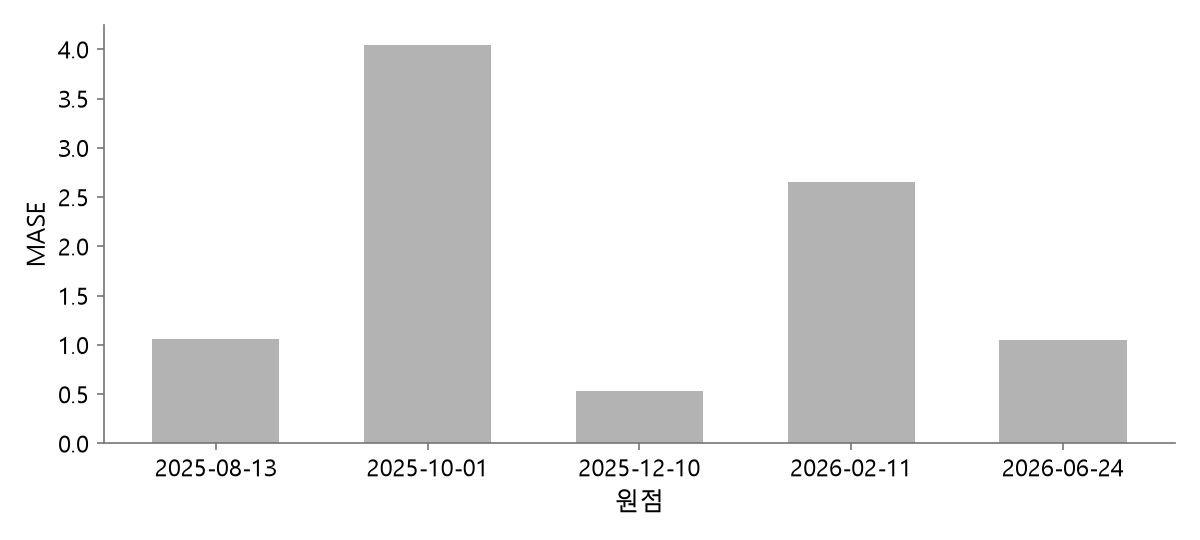

In [9]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다. 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 줄 아래를 다시 씁니다.
# 고칠 지시는 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 대화창에만 쓰면 진단은 나오지만 완성본 풀이가 열리지 않습니다
PROMPT = """
전임 담당자의 코드와 출력물을 보니까 입력 윈도에 원점이 모두 포함되어 있더라고 이게 문제가 있는 것 같아
이 부분을 수정하고 아래 기준으로 출력될 수 있도록 코드를 작성해줘
단 본문에 쓸 수 있는 것 미션 2 준비셀이 만든 이름은 그대로 사용해
1. 원점 전날에서 끝나는 입력 윈도 수: 단위 없음, 정수
2. 공휴일 없는 두 주 평균 MASE: 단위 없음, 소수 셋째자리
3. 그래프
원점 5개의 MASE 막대 5개
가로축 이름: 원점
세로축 이름: MASE
"""
# --- 여기부터 AI 코드 ---
mase_by, gap_by = {}, {}
for origin in ORIGINS:
    o = DATES.get_loc(origin)
    raw28 = MAT[:, o - 28:o]                  # 원점 전날까지 28일 (원점 당일은 빼야 누수가 없다)
    pred = mlp_forecast(origin, raw28)
    mase_by[origin] = score(MAT[:, o:o + H], pred, qden_of(origin))["mase"]
    first, last = DATES[o - 28], DATES[o - 1]
    gap_by[origin] = (origin - last).days     # 입력 끝날에서 원점까지 며칠인지
    print(f"원점 {origin.date()} | 입력 윈도 {first.date()} ~ {last.date()}"
          f" | 끝날에서 원점까지 {gap_by[origin]}일 | MASE {mase_by[origin]:.3f}")
print(f"원점 전날에서 끝나는 입력 윈도 수 = {sum(g == 1 for g in gap_by.values())}")
print(f"공휴일 없는 두 주 평균 MASE = {np.mean([mase_by[o] for o in PLAIN_ORIGINS]):.3f}")
print(f"공휴일 있는 세 주 평균 MASE = {np.mean([mase_by[o] for o in HOL_ORIGINS]):.3f}")
print(f"원점 5개 평균 MASE = {np.mean(list(mase_by.values())):.3f}")

fig, ax = plt.subplots(figsize=(FIG_W * 0.8, 3.6))
ax.bar([str(o.date()) for o in ORIGINS], list(mase_by.values()), color=COL["연회색"], width=0.6)
ax.set_xlabel("원점")
ax.set_ylabel("MASE")
plt.show()